# EDA: VIX-basiertes Ampel-System fuer die Morgenroutine

Ziel dieses Notebooks ist die explorative Analyse historischer VIX- und S&P-500-Daten, um eine sinnvolle Ampel-Logik (Gruen / Gelb / Rot) fuer den Marktzustand abzuleiten.

**Zu pruefende Hypothesen:**

1. Der VIX bewegt sich meist in einem ruhigen Band ("Normalzustand") und zeigt nur in Stressphasen (Finanzkrise 2008, Corona-Crash 2020, Inflations-Baisse 2022) deutliche Ausschlaege nach oben.
2. Hohe VIX-Werte korrelieren mit negativen/volatilen S&P-500-Renditen (inverse Beziehung VIX vs. Aktienmarkt).
3. Der VIX zeigt Volatility Clustering (Autokorrelation), d.h. hohe/niedrige Werte treten in Clustern auf - relevant fuer die Stabilitaet einer taeglichen Ampel.
4. Anhand der historischen Verteilung (Quantile) lassen sich plausible Schwellenwerte fuer Gruen/Gelb/Rot ableiten (z.B. grob orientiert an gaengigen Marktfaustregeln: <20 ruhig, 20-30 angespannt, >30 Ausnahmezustand) - wir pruefen, ob diese Faustregeln zu den Daten passen.
5. Der Uebergang zwischen den Zustaenden (z.B. Gruen -> Rot) - wie abrupt geschieht das, und wie lange dauern Rot-Phasen typischerweise?
"

## 1. Setup & Daten laden

Die Rohdaten wurden bereits per `src/fetch_data.py` von Yahoo Finance geladen und liegen als CSV in `data/` (VIX und S&P 500, taeglich, ab 2007-01-01).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

DATA_DIR = "../data"

# Ampel-Farben fuer konsistente Plots
COLOR_GREEN = "#2ca02c"
COLOR_YELLOW = "#f2c811"
COLOR_RED = "#d62728"

In [2]:
vix = pd.read_csv(f"{DATA_DIR}/vix_raw.csv", index_col="Date", parse_dates=True)
sp500 = pd.read_csv(f"{DATA_DIR}/sp500_raw.csv", index_col="Date", parse_dates=True)

print("VIX:", vix.shape, vix.index.min().date(), "-", vix.index.max().date())
print("S&P 500:", sp500.shape, sp500.index.min().date(), "-", sp500.index.max().date())

vix.head()

VIX: (4929, 6) 2007-01-03 - 2026-08-05
S&P 500: (4927, 6) 2007-01-03 - 2026-08-04


,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2007-01-03,12.04,12.04,12.75,11.53,12.16,0
2007-01-04,11.51,11.51,12.42,11.28,12.40,0
2007-01-05,12.14,12.14,12.25,11.68,11.84,0
2007-01-08,12.00,12.00,12.83,11.78,12.48,0
2007-01-09,11.91,11.91,12.47,11.69,11.86,0


## 2. Datenqualitaet

Pruefung auf fehlende Werte, Duplikate und abweichende Handelstage zwischen VIX und S&P 500 (z.B. durch unterschiedliche Feiertagskalender oder Datenluecken bei Yahoo Finance).

In [3]:
print("Fehlende Werte VIX:\
", vix.isna().sum())
print("\
Fehlende Werte S&P 500:\
", sp500.isna().sum())
print("\
Duplizierte Indexwerte VIX:", vix.index.duplicated().sum())
print("Duplizierte Indexwerte S&P 500:", sp500.index.duplicated().sum())

only_in_vix = vix.index.difference(sp500.index)
only_in_sp500 = sp500.index.difference(vix.index)
print(f"\
Handelstage nur im VIX: {len(only_in_vix)}")
print(f"Handelstage nur im S&P 500: {len(only_in_sp500)}")

Fehlende Werte VIX: Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64
Fehlende Werte S&P 500: Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64
Duplizierte Indexwerte VIX: 0
Duplizierte Indexwerte S&P 500: 0
Handelstage nur im VIX: 2
Handelstage nur im S&P 500: 0


In [4]:
df = pd.DataFrame({
    "vix_close": vix["Close"],
    "sp500_close": sp500["Close"],
}).dropna()

df["sp500_return"] = df["sp500_close"].pct_change() * 100  # in %
df["vix_change"] = df["vix_close"].diff()

print(f"Gemeinsame Handelstage: {len(df)}")
df.describe()

Gemeinsame Handelstage: 4927


,vix_close,sp500_close,sp500_return,vix_change
count,4927.000000,4927.000000,4926.000000,4926.000000
mean,19.788230,2804.092701,0.042198,0.000905
std,8.700132,1669.949594,1.241855,1.986202
min,9.140000,676.530029,-11.984055,-18.710003
25%,14.090000,1418.445007,-0.413199,-0.770000
50%,17.500000,2173.600098,0.072402,-0.110000
75%,22.695001,3958.670044,0.596015,0.600000
max,82.690002,7736.520020,11.580037,24.860001


## 3. Hypothese 1: Ruhiges Fahrwasser vs. Stressphasen

Zeitreihe des VIX ueber den gesamten Zeitraum mit bekannten Krisenphasen (Finanzkrise 2008, Corona-Crash 2020, Inflations-Baisse 2022) zur visuellen Einordnung.

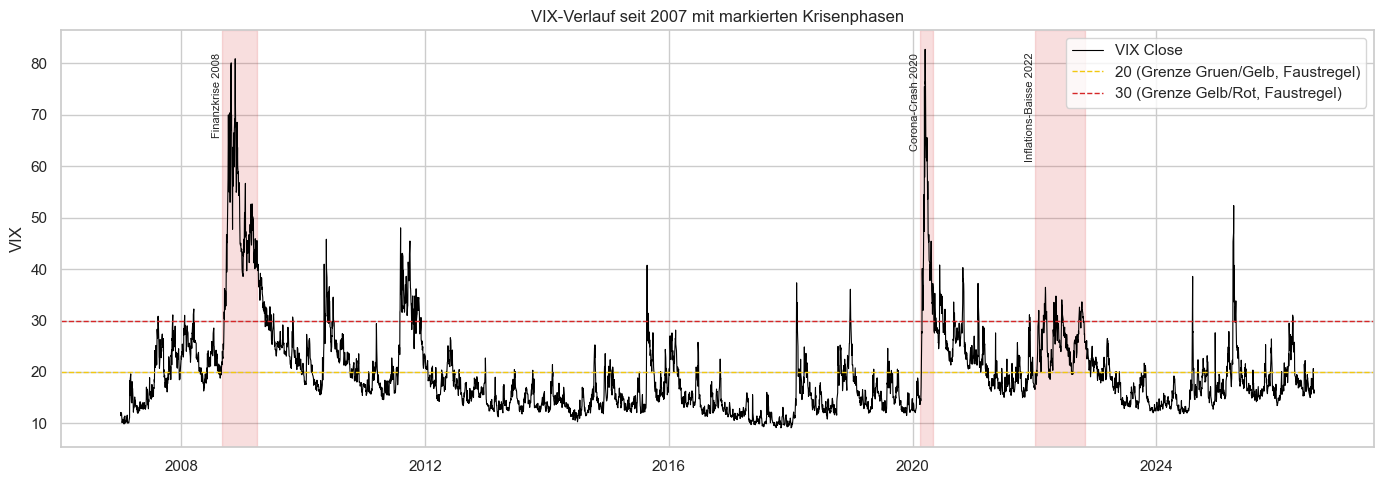

In [5]:
crisis_periods = {
    "Finanzkrise 2008": ("2008-09-01", "2009-03-31"),
    "Corona-Crash 2020": ("2020-02-15", "2020-04-30"),
    "Inflations-Baisse 2022": ("2022-01-01", "2022-10-31"),
}

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df["vix_close"], color="black", linewidth=0.8, label="VIX Close")

for label, (start, end) in crisis_periods.items():
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color=COLOR_RED, alpha=0.15)
    ax.text(pd.Timestamp(start), ax.get_ylim()[1] * 0.95, label, fontsize=8, rotation=90,
            va="top", ha="right")

ax.axhline(20, color=COLOR_YELLOW, linestyle="--", linewidth=1, label="20 (Grenze Gruen/Gelb, Faustregel)")
ax.axhline(30, color=COLOR_RED, linestyle="--", linewidth=1, label="30 (Grenze Gelb/Rot, Faustregel)")
ax.set_title("VIX-Verlauf seit 2007 mit markierten Krisenphasen")
ax.set_ylabel("VIX")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 4. Hypothese 4: Verteilung des VIX & plausible Ampel-Schwellenwerte

Histogramm und Quantile der VIX-Werte, um zu pruefen, wie gut gaengige Faustregel-Schwellen (20 / 30) zur tatsaechlichen Verteilung passen und welcher Anteil der Handelstage in welche Ampelphase faellt.

VIX-Quantile:
0.50    17.50
0.70    21.39
0.75    22.70
0.80    24.29
0.90    29.11
0.95    35.29
0.99    56.51
Name: vix_close, dtype: float64


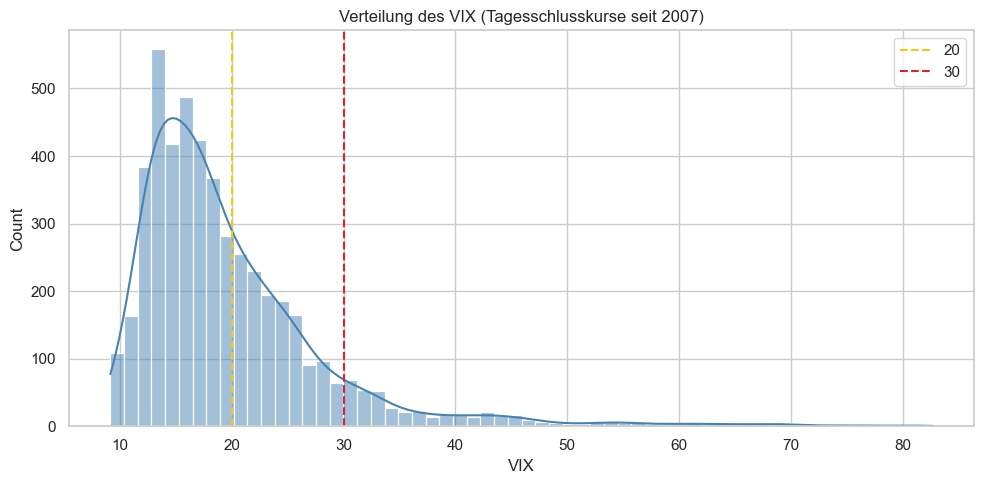

Gruen (<20): 64.1% der Handelstage
Gelb (20-30): 26.8% der Handelstage
Rot (>30): 9.1% der Handelstage


In [6]:
quantiles = df["vix_close"].quantile([0.5, 0.7, 0.75, 0.8, 0.9, 0.95, 0.99])
print("VIX-Quantile:")
print(quantiles.round(2))

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df["vix_close"], bins=60, kde=True, ax=ax, color="steelblue")
ax.axvline(20, color=COLOR_YELLOW, linestyle="--", label="20")
ax.axvline(30, color=COLOR_RED, linestyle="--", label="30")
ax.set_title("Verteilung des VIX (Tagesschlusskurse seit 2007)")
ax.set_xlabel("VIX")
ax.legend()
plt.tight_layout()
plt.show()

for low, high, label in [(0, 20, "Gruen (<20)"), (20, 30, "Gelb (20-30)"), (30, np.inf, "Rot (>30)")]:
    share = ((df["vix_close"] >= low) & (df["vix_close"] < high)).mean() * 100
    print(f"{label}: {share:.1f}% der Handelstage")

## 5. Hypothese 2: VIX vs. S&P-500-Renditen

Untersuchung des inversen Zusammenhangs: hohe VIX-Tagesaenderungen bzw. VIX-Niveaus sollten mit negativen/volatilen S&P-500-Tagesrenditen einhergehen.

Korrelation VIX-Tagesaenderung vs. S&P-500-Tagesrendite: -0.815
Korrelation VIX-Niveau vs. S&P-500-Tagesrendite: -0.143


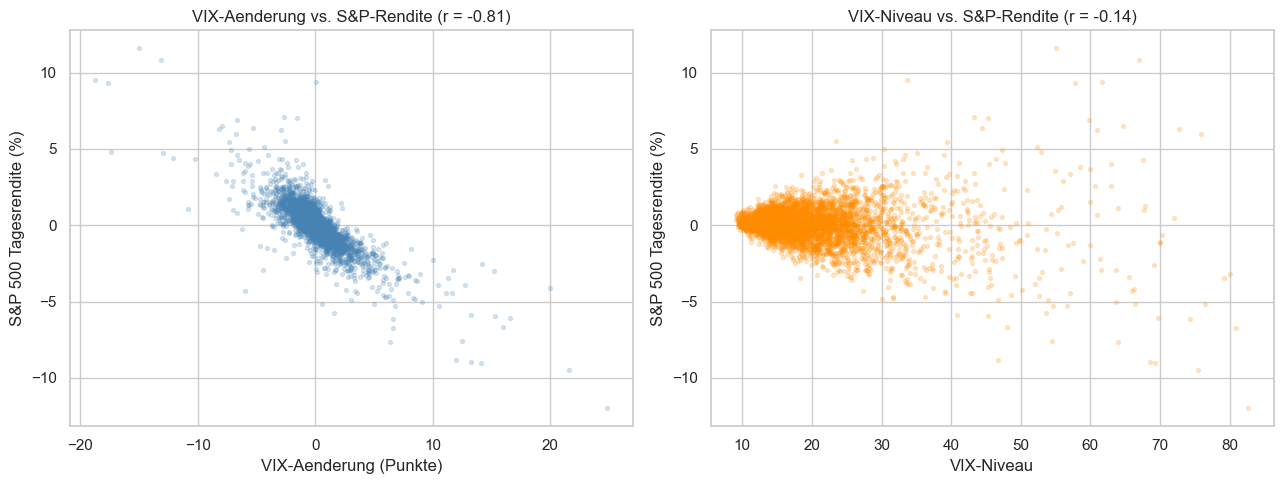

In [7]:
corr_change = df[["vix_change", "sp500_return"]].corr().iloc[0, 1]
corr_level = df[["vix_close", "sp500_return"]].corr().iloc[0, 1]
print(f"Korrelation VIX-Tagesaenderung vs. S&P-500-Tagesrendite: {corr_change:.3f}")
print(f"Korrelation VIX-Niveau vs. S&P-500-Tagesrendite: {corr_level:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(df["vix_change"], df["sp500_return"], alpha=0.2, s=8, color="steelblue")
axes[0].set_xlabel("VIX-Aenderung (Punkte)")
axes[0].set_ylabel("S&P 500 Tagesrendite (%)")
axes[0].set_title(f"VIX-Aenderung vs. S&P-Rendite (r = {corr_change:.2f})")

axes[1].scatter(df["vix_close"], df["sp500_return"], alpha=0.2, s=8, color="darkorange")
axes[1].set_xlabel("VIX-Niveau")
axes[1].set_ylabel("S&P 500 Tagesrendite (%)")
axes[1].set_title(f"VIX-Niveau vs. S&P-Rendite (r = {corr_level:.2f})")

plt.tight_layout()
plt.show()

## 6. Hypothese 3: Volatility Clustering (Autokorrelation)

Wenn der VIX stark autokorreliert ist, aendert sich die Ampelfarbe von Tag zu Tag selten sprunghaft - das ist fuer eine taegliche Morgenroutine wichtig (keine staendigen Fehlalarme durch Rauschen).

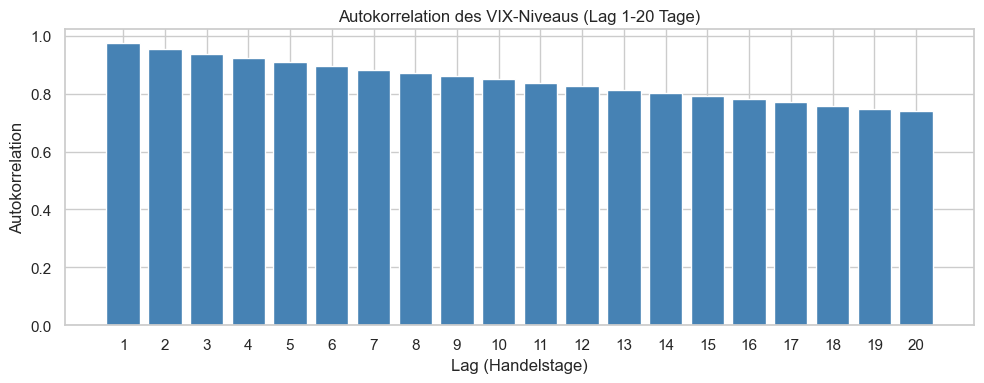

Autokorrelation Lag 1 (Vortag): 0.974
Autokorrelation Lag 5 (Vorwoche): 0.909


In [8]:
from pandas.plotting import autocorrelation_plot

lags = range(1, 21)
autocorrs = [df["vix_close"].autocorr(lag) for lag in lags]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(lags, autocorrs, color="steelblue")
ax.set_xlabel("Lag (Handelstage)")
ax.set_ylabel("Autokorrelation")
ax.set_title("Autokorrelation des VIX-Niveaus (Lag 1-20 Tage)")
ax.set_xticks(list(lags))
plt.tight_layout()
plt.show()

print(f"Autokorrelation Lag 1 (Vortag): {df['vix_close'].autocorr(1):.3f}")
print(f"Autokorrelation Lag 5 (Vorwoche): {df['vix_close'].autocorr(5):.3f}")

## 7. Hypothese 5: Dauer der Ampelphasen

Mit den Faustregel-Schwellen (20 / 30) klassifizieren wir jeden Handelstag in Gruen/Gelb/Rot und untersuchen, wie lange zusammenhaengende Phasen jeweils dauern - wichtig, um einzuschaetzen, ob die Ampel stabil genug fuer eine taegliche Routine ist.

In [9]:
def ampel(vix_value: float) -> str:
    if vix_value < 20:
        return "gruen"
    elif vix_value < 30:
        return "gelb"
    return "rot"

df["ampel"] = df["vix_close"].apply(ampel)

# zusammenhaengende Phasen identifizieren
phase_id = (df["ampel"] != df["ampel"].shift()).cumsum().rename("phase_id")
phases = df.groupby(phase_id).agg(
    ampel=("ampel", "first"),
    start=("ampel", lambda s: s.index[0]),
    ende=("ampel", lambda s: s.index[-1]),
    dauer_tage=("ampel", "size"),
)

print("Anzahl Phasenwechsel gesamt:", len(phases))
print("\
Durchschnittliche Phasendauer (Handelstage) je Ampelfarbe:")
print(phases.groupby("ampel")["dauer_tage"].describe()[["count", "mean", "50%", "max"]])

print("\
Die 5 laengsten Rot-Phasen:")
print(phases[phases["ampel"] == "rot"].sort_values("dauer_tage", ascending=False).head())

Anzahl Phasenwechsel gesamt: 404
Durchschnittliche Phasendauer (Handelstage) je Ampelfarbe:
       count       mean  50%    max
ampel                              
gelb   201.0   6.567164  2.0   80.0
gruen  150.0  21.053333  4.0  312.0
rot     53.0   8.471698  2.0  170.0
Die 5 laengsten Rot-Phasen:
         ampel      start       ende  dauer_tage
phase_id                                        
33         rot 2008-09-15 2009-05-18         170
101        rot 2011-08-04 2011-10-13          50
230        rot 2020-02-27 2020-05-07          50
109        rot 2011-11-09 2011-11-29          14
236        rot 2020-06-11 2020-06-30          14


## 9. Vertiefende Hypothesen fuer die Ampel-Logik

Die folgenden vier Abschnitte pruefen spezifische, fuer die Ampel-Logik relevante Hypothesen. Jeder Abschnitt enthaelt Code, eine Visualisierung und eine kurze Ergebnis-Interpretation.

Als gemeinsame Referenzgroesse wird der VIX-Schwellenwert 30 verwendet (gaengige Marktfaustregel fuer den "Ausnahmezustand"/Rot-Bereich, siehe auch Abschnitt 4 oben). Abschnitt 11 ("VIX-Schwellenwerte") ueberprueft explizit, ob sich dieser Wert anhand der Daten bestaetigen laesst.

In [10]:
# Gemeinsame Konfiguration fuer die folgenden Abschnitte
VIX_THRESHOLD_ROT = 30  # Faustregel-Schwelle "Ausnahmezustand", wird in Abschnitt 11 validiert


def forward_hit_rate(signal_mask, horizon, threshold=VIX_THRESHOLD_ROT):
    """Anteil der Tage mit signal_mask == True, an denen der VIX-Schlusskurs
    innerhalb der naechsten `horizon` Handelstage mindestens einmal ueber
    `threshold` steigt. Tage ohne vollstaendiges Folgefenster (zu nah am
    Datenende) werden ausgeschlossen."""
    vix_values = df["vix_close"].values
    mask_values = signal_mask.values if hasattr(signal_mask, "values") else signal_mask
    idx = np.where(mask_values)[0]
    hits, valid = 0, 0
    for i in idx:
        window = vix_values[i + 1 : i + 1 + horizon]
        if len(window) == 0:
            continue  # kein vollstaendiges Folgefenster mehr vorhanden
        valid += 1
        if window.max() > threshold:
            hits += 1
    return hits / valid if valid else np.nan


ALL_DAYS = pd.Series(True, index=df.index)

### 9.1 Hypothese: Neues 3-Monats-Hoch als Fruehwarnsignal

**Fragestellung:** Wenn der VIX ein neues 3-Monats-Hoch erreicht (hoechster Schlusskurs der letzten ca. 63 Handelstage, also 3 Kalendermonate zu je ~21 Handelstagen), wie oft folgt in den naechsten 5 bzw. 10 Handelstagen tatsaechlich eine Phase mit VIX > 30? Wir berechnen die Trefferquote und vergleichen sie mit der unbedingten Basis-Wahrscheinlichkeit, um den Mehrwert des Signals einzuordnen.

In [11]:
# Rollierendes 3-Monats-Hoch VOR dem aktuellen Tag berechnen. shift(1) stellt sicher,
# dass der aktuelle Tag selbst nicht im Vergleichsfenster enthalten ist (kein Blick in die Zukunft).
WINDOW_3M = 63
rolling_high_3m = df["vix_close"].shift(1).rolling(WINDOW_3M).max()

# Signaltage: aktueller Schlusskurs liegt ueber dem rollierenden 3-Monats-Hoch
new_3m_high = df["vix_close"] > rolling_high_3m
print(f"Anzahl Signaltage (neues 3-Monats-Hoch): {int(new_3m_high.sum())}")

hit_rate_5 = forward_hit_rate(new_3m_high, horizon=5)
hit_rate_10 = forward_hit_rate(new_3m_high, horizon=10)
baseline_5 = forward_hit_rate(ALL_DAYS, horizon=5)
baseline_10 = forward_hit_rate(ALL_DAYS, horizon=10)

print(f"Trefferquote nach Signal, 5 Tage:  {hit_rate_5:.1%}  (Baseline: {baseline_5:.1%})")
print(f"Trefferquote nach Signal, 10 Tage: {hit_rate_10:.1%}  (Baseline: {baseline_10:.1%})")

Anzahl Signaltage (neues 3-Monats-Hoch): 153
Trefferquote nach Signal, 5 Tage:  39.2%  (Baseline: 12.3%)
Trefferquote nach Signal, 10 Tage: 41.8%  (Baseline: 15.2%)


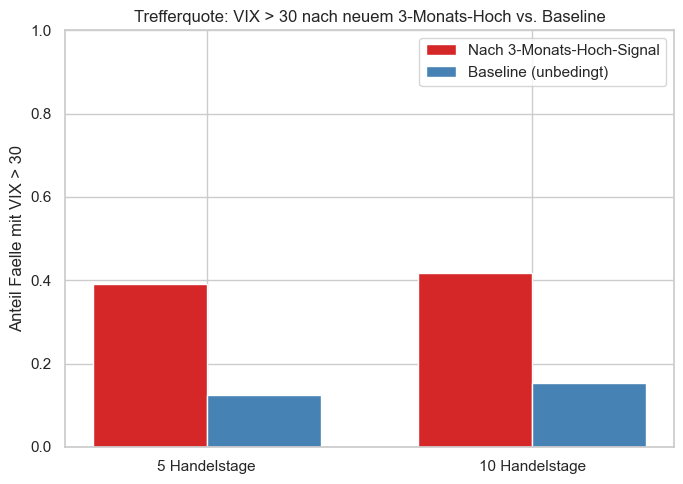

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))
labels = ["5 Handelstage", "10 Handelstage"]
signal_rates = [hit_rate_5, hit_rate_10]
baseline_rates = [baseline_5, baseline_10]
x = np.arange(len(labels))
width = 0.35

ax.bar(x - width / 2, signal_rates, width, label="Nach 3-Monats-Hoch-Signal", color=COLOR_RED)
ax.bar(x + width / 2, baseline_rates, width, label="Baseline (unbedingt)", color="steelblue")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel(f"Anteil Faelle mit VIX > {VIX_THRESHOLD_ROT}")
ax.set_ylim(0, 1)
ax.set_title("Trefferquote: VIX > 30 nach neuem 3-Monats-Hoch vs. Baseline")
ax.legend()
plt.tight_layout()
plt.show()

**Ergebnis:** Ueber den Beobachtungszeitraum gab es 153 neue 3-Monats-Hochs. Nach einem solchen Signal lag der VIX in 39,2% der Faelle innerhalb von 5 Handelstagen und in 41,8% der Faelle innerhalb von 10 Handelstagen mindestens einmal ueber 30 -- gegenueber einer unbedingten Basiswahrscheinlichkeit von nur 12,3% bzw. 15,2%. Das Signal erhoeht die Trefferquote also etwa um den Faktor 3, bleibt aber mit ~40% ein Minderheits-Ereignis und damit kein zuverlaessiger Alleinauftrag fuer die Ampel. Hinweis: Da VIX-Anstiege oft mehrere Tage in Folge neue Hochs erzeugen, sind die Signaltage nicht vollstaendig unabhaengig voneinander, was die Trefferquote tendenziell etwas nach oben verzerren kann.

### 9.2 Hypothese: "3-Punkte-Umkehr" als Beruhigungssignal

**Fragestellung:** Definiere Tage, an denen gilt: Open >= 20 UND Intraday-High > Open UND (Intraday-High - Close) >= 3 -- der VIX schiesst also im Tagesverlauf deutlich nach oben, gibt den Anstieg bis zum Handelsschluss aber wieder groesstenteils ab. Faellt der VIX an den 5 Folgetagen im Schnitt (= Beruhigung) oder steigt er haeufig weiter?

In [13]:
# Signal-Definition: ausgepraegte Intraday-Umkehr im VIX
#   - Open >= 20            -> Markt startet bereits angespannt
#   - High > Open            -> im Tagesverlauf zieht der VIX weiter an
#   - (High - Close) >= 3    -> der Tag schliesst aber mindestens 3 Punkte unter dem Hoch
vix_ohlc = vix[["Open", "High", "Low", "Close"]].reindex(df.index)

reversal_signal = (
    (vix_ohlc["Open"] >= 20)
    & (vix_ohlc["High"] > vix_ohlc["Open"])
    & ((vix_ohlc["High"] - vix_ohlc["Close"]) >= 3)
)
signal_dates = df.index[reversal_signal.values]
print(f"Anzahl '3-Punkte-Umkehr'-Signale: {len(signal_dates)}")

# VIX-Entwicklung an den 5 Folgetagen, relativ zum Schlusskurs des Signaltags
HORIZON_H2 = 5
vix_close_values = df["vix_close"]
paths = []
for date in signal_dates:
    pos = df.index.get_loc(date)
    if pos + HORIZON_H2 >= len(df):
        continue  # nicht genug Folgetage vorhanden
    base = vix_close_values.iloc[pos]
    path = vix_close_values.iloc[pos : pos + HORIZON_H2 + 1].values - base
    paths.append(path)
paths = np.array(paths)

mean_path = paths.mean(axis=0)
median_path = np.median(paths, axis=0)
share_falling = (paths[:, -1] < 0).mean()

print(f"Auswertbare Signale: {len(paths)}")
print(f"Durchschnittliche VIX-Aenderung nach {HORIZON_H2} Tagen: {mean_path[-1]:+.2f} Punkte")
print(f"Median VIX-Aenderung nach {HORIZON_H2} Tagen:            {median_path[-1]:+.2f} Punkte")
print(f"Anteil Faelle mit niedrigerem VIX nach {HORIZON_H2} Tagen: {share_falling:.1%}")

Anzahl '3-Punkte-Umkehr'-Signale: 272


Auswertbare Signale: 272
Durchschnittliche VIX-Aenderung nach 5 Tagen: -1.51 Punkte
Median VIX-Aenderung nach 5 Tagen:            -2.02 Punkte
Anteil Faelle mit niedrigerem VIX nach 5 Tagen: 67.3%


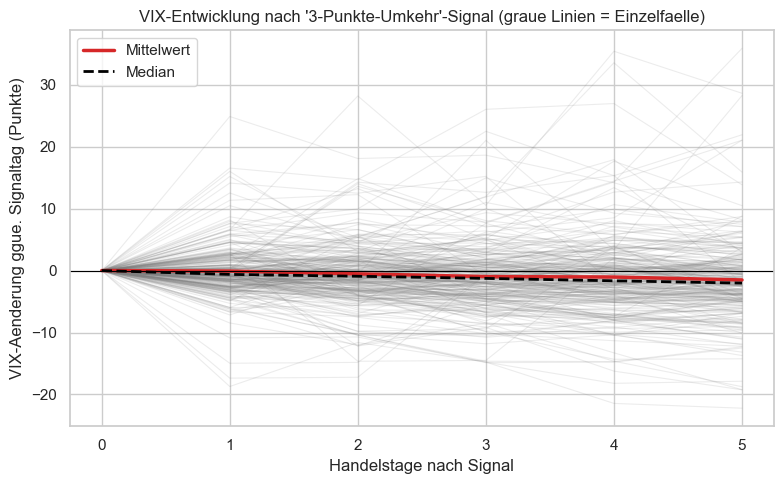

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
days = np.arange(0, HORIZON_H2 + 1)
for path in paths:
    ax.plot(days, path, color="grey", alpha=0.15, linewidth=0.8)
ax.plot(days, mean_path, color=COLOR_RED, linewidth=2.5, label="Mittelwert")
ax.plot(days, median_path, color="black", linewidth=2, linestyle="--", label="Median")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Handelstage nach Signal")
ax.set_ylabel("VIX-Aenderung ggue. Signaltag (Punkte)")
ax.set_title("VIX-Entwicklung nach '3-Punkte-Umkehr'-Signal (graue Linien = Einzelfaelle)")
ax.legend()
plt.tight_layout()
plt.show()

**Ergebnis:** Von 272 identifizierten '3-Punkte-Umkehr'-Signalen fiel der VIX in 67,3% der Faelle innerhalb von 5 Handelstagen unter den Stand des Signaltags, im Schnitt um 1,51 Punkte (Median: -2,02 Punkte). Die Hypothese der Beruhigung wird damit tendenziell bestaetigt: in etwa zwei von drei Faellen deutet das Muster tatsaechlich auf ein nachlassendes Stresslevel hin, in knapp einem Drittel der Faelle setzt sich der Anstieg jedoch fort -- das Signal ist also ein nuetzlicher, aber kein eindeutiger Indikator.

### 9.3 Hypothese: VIX-Schwellenwerte anhand Verteilung und Stressphasen

**Fragestellung:** Wie ist der VIX ueber den gesamten Zeitraum verteilt (Perzentile 50/75/90/95)? Und ab welchem Niveau heben sich bekannte Stressphasen (Finanzkrise 2008, Covid-Crash 2020, Inflations-Baisse 2022) im Zeitverlauf sichtbar vom Normalzustand ab? Daraus leiten wir sinnvolle Schwellen fuer Gelb/Rot ab. Die Krisenphasen (`crisis_periods`) wurden bereits in Abschnitt 3 definiert und werden hier wiederverwendet.

In [15]:
percentiles_h3 = df["vix_close"].quantile([0.50, 0.75, 0.90, 0.95])
print("VIX-Perzentile (gesamter Zeitraum):")
print(percentiles_h3.round(2))

# Boolesche Maske: Tag liegt innerhalb einer der definierten Stressphasen
in_crisis = pd.Series(False, index=df.index)
for start, end in crisis_periods.values():
    in_crisis |= (df.index >= start) & (df.index <= end)

print("\nVIX waehrend Stressphasen (Median / Min / Max):")
print(df.loc[in_crisis, "vix_close"].agg(["median", "min", "max"]).round(2))
print("\nVIX ausserhalb von Stressphasen (Median / Min / Max):")
print(df.loc[~in_crisis, "vix_close"].agg(["median", "min", "max"]).round(2))

VIX-Perzentile (gesamter Zeitraum):
0.50    17.50
0.75    22.70
0.90    29.11
0.95    35.29
Name: vix_close, dtype: float64

VIX waehrend Stressphasen (Median / Min / Max):
median    31.77
min       14.38
max       82.69
Name: vix_close, dtype: float64

VIX ausserhalb von Stressphasen (Median / Min / Max):
median    16.90
min        9.14
max       52.33
Name: vix_close, dtype: float64


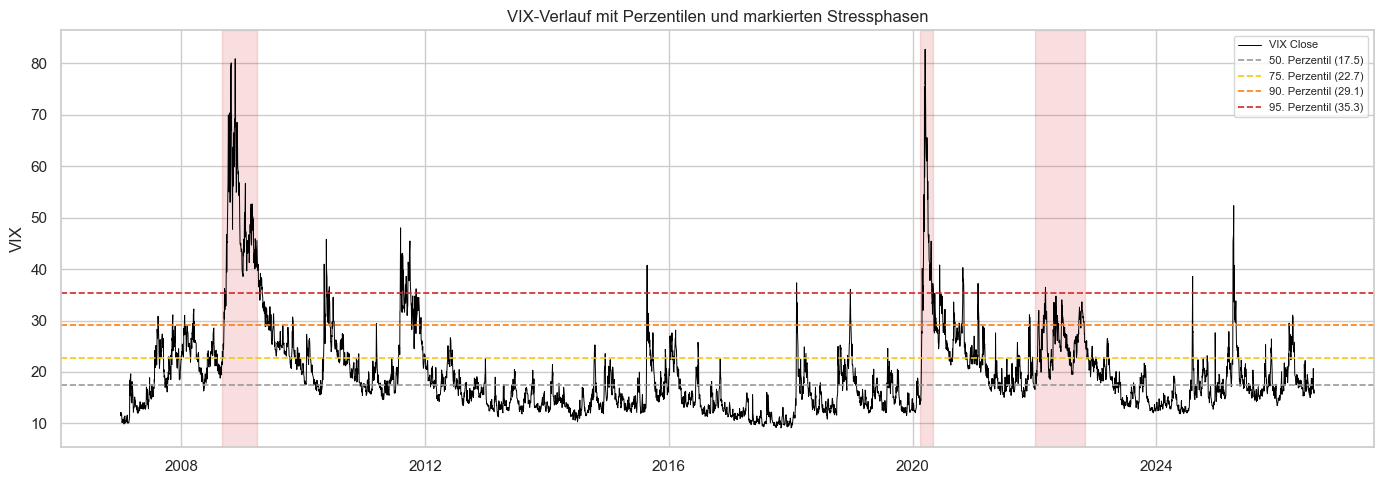

In [16]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df["vix_close"], color="black", linewidth=0.7, label="VIX Close")

for label, (start, end) in crisis_periods.items():
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color=COLOR_RED, alpha=0.15)

percentile_colors = ["#999999", COLOR_YELLOW, "#ff7f0e", COLOR_RED]
for (q, val), color in zip(percentiles_h3.items(), percentile_colors):
    ax.axhline(val, linestyle="--", linewidth=1.2, color=color,
               label=f"{int(q * 100)}. Perzentil ({val:.1f})")

ax.set_title("VIX-Verlauf mit Perzentilen und markierten Stressphasen")
ax.set_ylabel("VIX")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

**Ergebnis:** Die Perzentile (50/75/90/95 = 17,5/22,7/29,1/35,3) zeigen, dass der Median-VIX waehrend der markierten Stressphasen (31,77) nahe am 90. Perzentil der Gesamtverteilung liegt und deutlich ueber dem 75. Perzentil -- die bisherige Faustregel-Schwelle von 30 fuer 'Rot' ist damit gut durch die Daten gedeckt, waehrend sich 'Gelb' eher im Bereich des 75.-90. Perzentils (ca. 20-29) verorten laesst. Allerdings zeigt der Minimalwert von 14,38 innerhalb der Stressphasen und der Maximalwert von 52,33 ausserhalb, dass die grob definierten Kalenderfenster nicht trennscharf sind: einzelne ruhige Tage fallen in Krisenzeitraeume und umgekehrt loesen auch ausserhalb der markierten Phasen kurzzeitig hohe VIX-Spitzen aus (z.B. Einzeltagesereignisse).

### 9.4 Hypothese: Divergenz zum Index als Fruehindikator

**Fragestellung:** Normalerweise sind VIX und S&P 500 invers korreliert (vgl. Abschnitt 5). Wie oft steigen beide an einem Handelstag gleichzeitig ("untypischer Gleichlauf")? Wir berechnen dazu den Anteil solcher Tage in einem rollierenden 5- bzw. 10-Tage-Fenster und pruefen, ob ein hoher Anteil (>60%) historisch mit nachfolgenden Marktturbulenzen einhergeht. Als Turbulenz-Definition verwenden wir konsistent zu Abschnitt 9.1: VIX > 30 innerhalb der naechsten 10 Handelstage.

In [17]:
# Tage, an denen S&P 500 UND VIX am selben Tag gleichzeitig gestiegen sind
co_up = (df["sp500_return"] > 0) & (df["vix_change"] > 0)

share_5d = co_up.rolling(5).mean()
share_10d = co_up.rolling(10).mean()

DIVERGENCE_THRESHOLD = 0.6
high_divergence_5d = share_5d > DIVERGENCE_THRESHOLD

print(f"Tage mit >{DIVERGENCE_THRESHOLD:.0%} Gleichlauf im 5-Tage-Fenster: "
      f"{int(high_divergence_5d.sum())} von {int(share_5d.notna().sum())} "
      f"({high_divergence_5d.mean():.1%})")

# Turbulenz-Wahrscheinlichkeit nach Divergenz-Signal vs. Baseline (baseline_10 aus Abschnitt 9.1,
# identische Definition: VIX > 30 in den naechsten 10 Handelstagen)
turbulence_after_divergence = forward_hit_rate(high_divergence_5d, horizon=10)

print(f"P(VIX > {VIX_THRESHOLD_ROT} in den naechsten 10 Tagen | Divergenz > {DIVERGENCE_THRESHOLD:.0%}): "
      f"{turbulence_after_divergence:.1%}")
print(f"P(VIX > {VIX_THRESHOLD_ROT} in den naechsten 10 Tagen), Baseline: {baseline_10:.1%}")

Tage mit >60% Gleichlauf im 5-Tage-Fenster: 5 von 4923 (0.1%)
P(VIX > 30 in den naechsten 10 Tagen | Divergenz > 60%): 0.0%
P(VIX > 30 in den naechsten 10 Tagen), Baseline: 15.2%


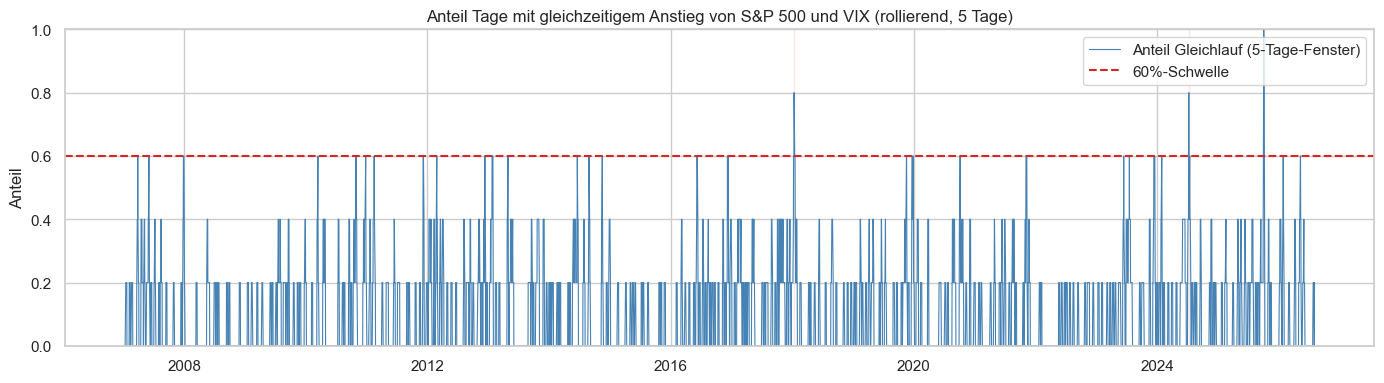

In [18]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df.index, share_5d, color="steelblue", linewidth=0.8, label="Anteil Gleichlauf (5-Tage-Fenster)")
ax.axhline(DIVERGENCE_THRESHOLD, color=COLOR_RED, linestyle="--", label=f"{DIVERGENCE_THRESHOLD:.0%}-Schwelle")
ax.fill_between(df.index, 0, 1, where=high_divergence_5d.fillna(False).values, color=COLOR_RED, alpha=0.1)
ax.set_ylim(0, 1)
ax.set_title("Anteil Tage mit gleichzeitigem Anstieg von S&P 500 und VIX (rollierend, 5 Tage)")
ax.set_ylabel("Anteil")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

**Ergebnis:** Ein gleichzeitiger Anstieg von S&P 500 und VIX an mindestens 60% der Tage eines 5-Tage-Fensters ist mit 5 von 4.923 Fenstern (0,1%) ein extrem seltenes Ereignis. In diesen wenigen Faellen folgte in keinem einzigen (0,0%) innerhalb von 10 Handelstagen eine Phase mit VIX > 30, gegenueber einer Basiswahrscheinlichkeit von 15,2% -- die Hypothese wird in dieser Form durch die Daten nicht gestuetzt. Wichtiger Vorbehalt: Mit nur 5 Beobachtungen ist die Stichprobe viel zu klein fuer eine belastbare Aussage; fuer die Ampel-Logik waere entweder eine weniger strenge Divergenz-Definition (z.B. niedrigerer Schwellenwert oder laengeres Fenster) oder ein laengerer Beobachtungszeitraum noetig, um genug Faelle fuer eine verlaessliche Einschaetzung zu erhalten.

### 9.4 (Fortsetzung): Varianten-Vergleich der Divergenz-Parameter

Die Basis-Analyse in Abschnitt 9.4 (Fenster = 5 Tage, Schwelle = 60 %, Anstiegstag = Index-Rendite > 0 %) lieferte nur 5 Signale und ist damit statistisch nicht belastbar. Um zu pruefen, wie sensibel das Ergebnis auf die Parameterwahl reagiert, variieren wir systematisch drei Stellschrauben und halten sonst die identische Logik bei (Turbulenz-Definition unveraendert: VIX > 30 in den naechsten 10 Handelstagen):

- **Fenstergroesse** des rollierenden Anteils (5 / 10 / 20 Handelstage),
- **Anteils-Schwelle**, ab der ein Fenster als "auffaelliger Gleichlauf" gilt (60 % / 20 %),
- **Definition eines Anstiegstags** (Index-Rendite > 0 % vs. mindestens 0,25 %).

**Zur Wahl des Rendite-Schwellenwerts (Block 4):** Die geforderten 0,25 % sind bewusst knapp oberhalb des Rauschens angesetzt. Die taegliche S&P-500-Rendite hat im Datensatz eine Standardabweichung von rund 1,24 %; eine Bewegung von 0,25 % entspricht damit etwa 0,2 Standardabweichungen und filtert Nulllinien-/Mini-Bewegungen heraus, ohne bereits echte Aufwaertstage auszuschliessen. Der Wert erscheint statistisch sinnvoll und wird daher wie vorgeschlagen mit 0,25 % festgelegt. (Hinweis: Da Tagesrenditen stetig sind, ist die Bedingung "> 0,25 %" praktisch identisch mit "mindestens 0,25 %".)


In [19]:
# Wiederverwendbare Funktion fuer die Divergenz-Varianten.
# Sie kapselt exakt die Logik aus Abschnitt 9.4, macht aber Fenstergroesse,
# Anteils-Schwelle und die Mindest-Tagesrendite fuer einen "Anstiegstag" variabel.
variant_results = {}

# Original-Variante aus 9.4 zum Vergleich registrieren (Werte stammen aus dem obigen Block)
variant_results["Original (5T / 60% / >0%)"] = {
    "fenster": 5, "schwelle": 0.60, "rendite_min": 0.0,
    "n_signale": int(high_divergence_5d.sum()),
    "n_fenster": int(share_5d.notna().sum()),
    "trefferquote": turbulence_after_divergence,
}


def run_divergence_variant(name, window, threshold, ret_min):
    """Fuehrt die Divergenz-Analyse aus 9.4 mit variablen Parametern aus,
    speichert die Kennzahlen in variant_results und plottet den rollierenden
    Gleichlauf-Anteil. Rueckgabe: (share, high_div) fuer optionale Weiterverwendung."""
    # "Anstiegstag" = S&P-Rendite ueber Schwelle UND VIX am selben Tag gestiegen
    co_up_local = (df["sp500_return"] > ret_min) & (df["vix_change"] > 0)
    share = co_up_local.rolling(window).mean()
    high_div = share > threshold

    n_signal = int(high_div.sum())
    n_windows = int(share.notna().sum())
    hit = forward_hit_rate(high_div, horizon=10)

    variant_results[name] = {
        "fenster": window, "schwelle": threshold, "rendite_min": ret_min,
        "n_signale": n_signal, "n_fenster": n_windows, "trefferquote": hit,
    }

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(df.index, share, color="steelblue", linewidth=0.8,
            label=f"Anteil Gleichlauf ({window}-Tage-Fenster)")
    ax.axhline(threshold, color=COLOR_RED, linestyle="--", label=f"{threshold:.0%}-Schwelle")
    ax.fill_between(df.index, 0, 1, where=high_div.fillna(False).values,
                    color=COLOR_RED, alpha=0.1)
    ax.set_ylim(0, 1)
    ax.set_title(f"{name}: Gleichlauf S&P 500 & VIX (Fenster={window}, "
                 f"Schwelle={threshold:.0%}, Index-Rendite>{ret_min:.2f}%)")
    ax.set_ylabel("Anteil")
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

    hit_str = f"{hit:.1%}" if pd.notna(hit) else "n/a (keine Signale)"
    print(f"Signale: {n_signal} von {n_windows} Fenstern ({n_signal / n_windows:.2%})")
    print(f"P(VIX > {VIX_THRESHOLD_ROT} in 10 Tagen | Signal): {hit_str}  "
          f"(Baseline: {baseline_10:.1%})")
    return share, high_div


#### Block 1: Fenster 10 Tage (Schwelle 60 %, Rendite > 0 %)

Identische Logik wie 9.4, nur das rollierende Fenster wird von 5 auf 10 Handelstage verlaengert.


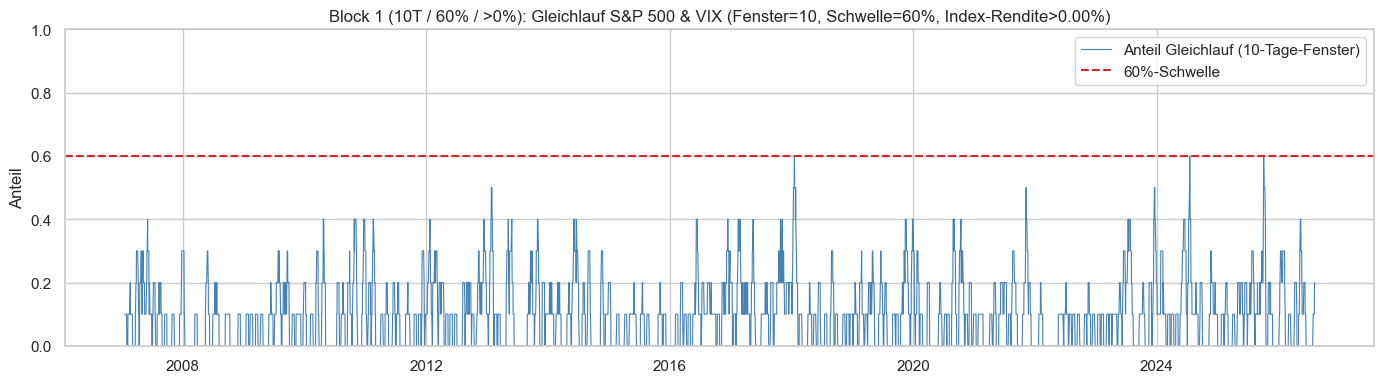

Signale: 0 von 4918 Fenstern (0.00%)
P(VIX > 30 in 10 Tagen | Signal): n/a (keine Signale)  (Baseline: 15.2%)


In [20]:
_ = run_divergence_variant("Block 1 (10T / 60% / >0%)", window=10, threshold=0.6, ret_min=0.0)


**Interpretation:** Mit einem 10-Tage-Fenster tritt kein einziges Signal mehr auf (0 von 4.918 Fenstern). Da ein gleichzeitiger Anstieg von S&P 500 und VIX historisch nur an rund 20 % aller Tage vorkommt, ist ein Anteil von ueber 60 % ueber zehn Tage praktisch unerreichbar. Die Verlaengerung des Fensters macht die 60 %-Schwelle also noch strenger und die Variante fuer die Praxis unbrauchbar.

#### Block 2: Fenster 20 Tage (Schwelle 60 %, Rendite > 0 %)

Identische Logik wie 9.4, das rollierende Fenster wird auf 20 Handelstage verlaengert.


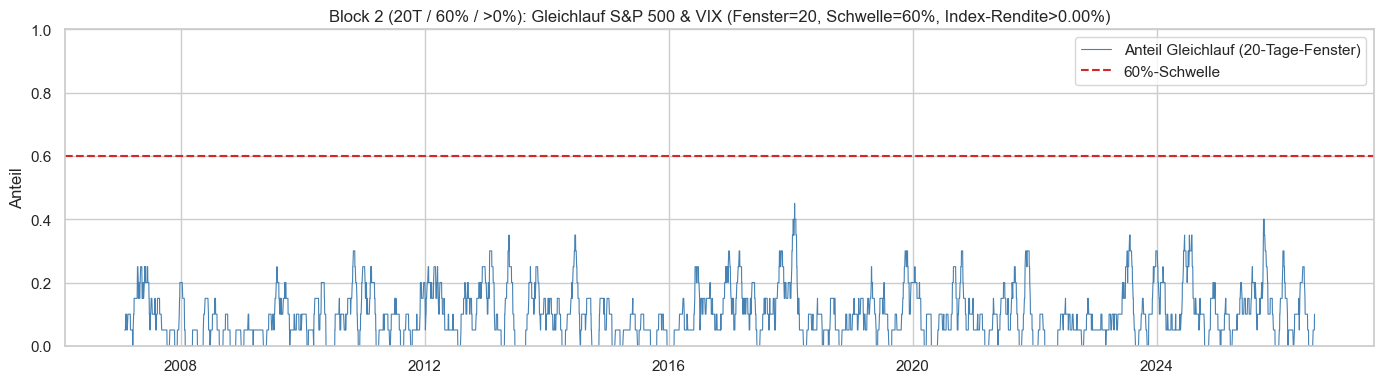

Signale: 0 von 4908 Fenstern (0.00%)
P(VIX > 30 in 10 Tagen | Signal): n/a (keine Signale)  (Baseline: 15.2%)


In [21]:
_ = run_divergence_variant("Block 2 (20T / 60% / >0%)", window=20, threshold=0.6, ret_min=0.0)


**Interpretation:** Auch mit 20-Tage-Fenster bleibt die 60 %-Schwelle bei 0 Signalen (von 4.908 Fenstern) voellig leer -- ueber einen ganzen Handelsmonat einen 60-prozentigen Gleichlauf zu erreichen, ist im Beobachtungszeitraum nie vorgekommen. Eine so strenge Kombination liefert damit grundsaetzlich keine verwertbaren Signale.

#### Block 3: Anteils-Schwelle 20 % (Fenster 5 Tage, Rendite > 0 %)

Identische Logik wie 9.4, aber die Schwelle fuer "auffaelligen Gleichlauf" wird von 60 % auf 20 % gesenkt.


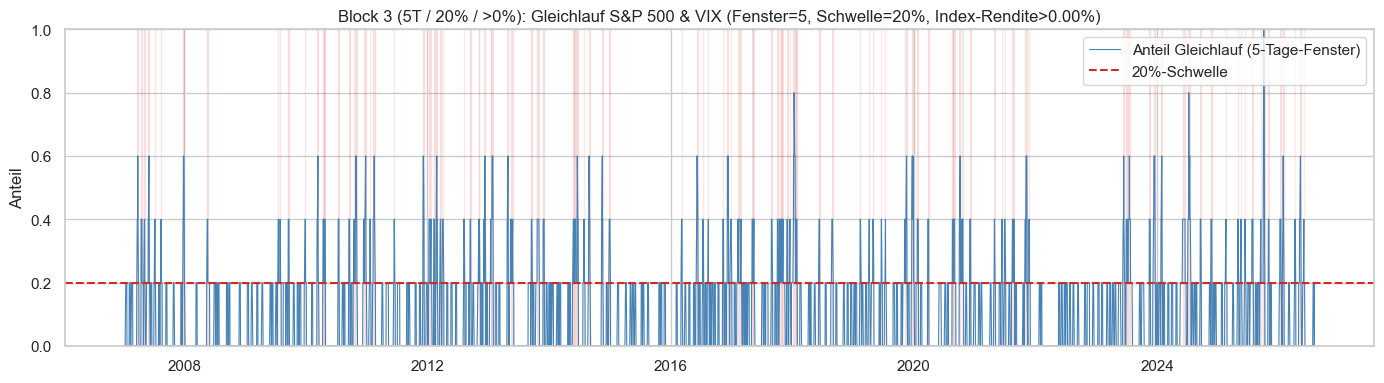

Signale: 471 von 4923 Fenstern (9.57%)
P(VIX > 30 in 10 Tagen | Signal): 6.2%  (Baseline: 15.2%)


In [22]:
_ = run_divergence_variant("Block 3 (5T / 20% / >0%)", window=5, threshold=0.2, ret_min=0.0)


**Interpretation:** Das Absenken der Schwelle auf 20 % erzeugt mit 471 Signalen (9,6 % aller Fenster) erstmals eine grosse Stichprobe. Die Trefferquote liegt mit 6,2 % jedoch deutlich UNTER der Baseline von 15,2 %. Kurzfristige Gleichlauf-Cluster gehen historisch also eher mit ruhigeren als mit turbulenteren Folgephasen einher -- die Divergenz-Hypothese wird in dieser Form nicht nur nicht bestaetigt, sondern tendenziell sogar umgekehrt.

#### Block 4: Anstiegstag = Index-Rendite mindestens 0,25 % (Fenster 5 Tage, Schwelle 60 %)

Identische Basis wie 9.4, aber ein Tag zaehlt nur dann als "gemeinsamer Anstiegstag", wenn die S&P-500-Tagesrendite mindestens 0,25 % betraegt (statt nur > 0 %). Damit werden Mini-/Rauschbewegungen des Index herausgefiltert (Begruendung siehe Einleitung oben).


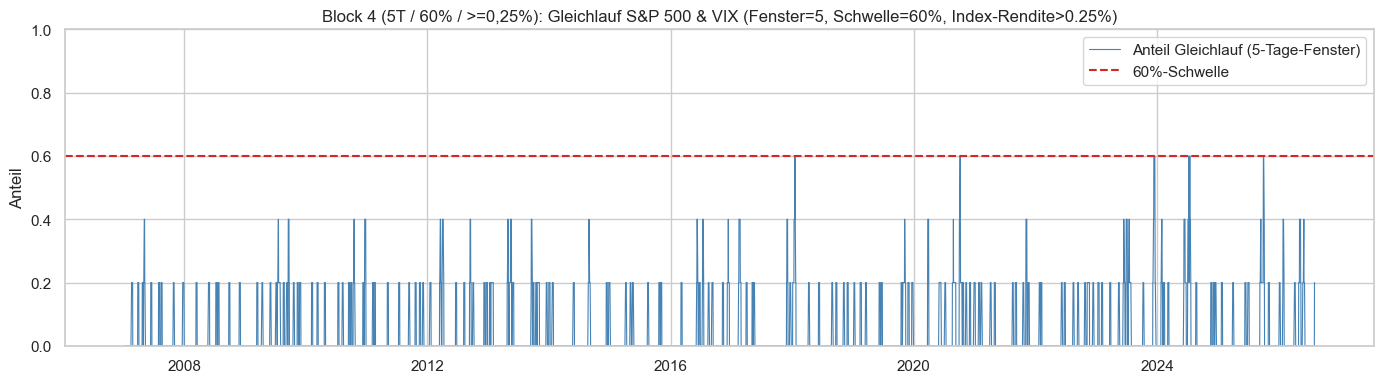

Signale: 0 von 4923 Fenstern (0.00%)
P(VIX > 30 in 10 Tagen | Signal): n/a (keine Signale)  (Baseline: 15.2%)


In [23]:
_ = run_divergence_variant("Block 4 (5T / 60% / >=0,25%)", window=5, threshold=0.6, ret_min=0.25)


**Interpretation:** Der zusaetzliche Rendite-Filter (Index-Anstieg mindestens 0,25 %) reduziert die Zahl der Anstiegstage weiter, sodass die ohnehin sehr strenge 60 %-Schwelle im 5-Tage-Fenster gar nicht mehr erreicht wird (0 Signale). Die Kombination aus hoher Schwelle und Rendite-Filter ist damit zu restriktiv fuer eine belastbare Auswertung.

#### Block 5: Kombination Fenster 10 Tage + Schwelle 20 % + Rendite mindestens 0,25 %

Kombiniert die Anpassungen aus Block 1 (Fenster 10), Block 3 (Schwelle 20 %) und Block 4 (Rendite >= 0,25 %).


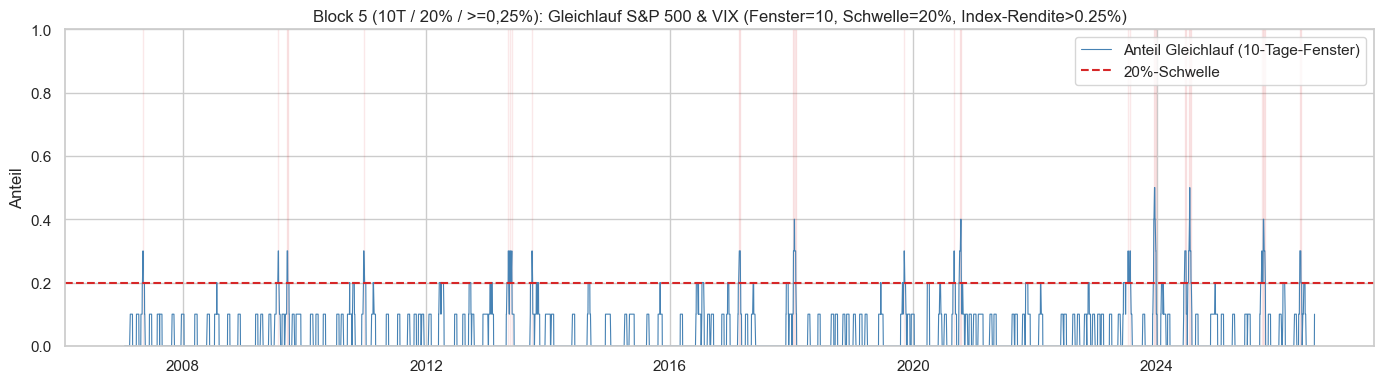

Signale: 88 von 4918 Fenstern (1.79%)
P(VIX > 30 in 10 Tagen | Signal): 11.4%  (Baseline: 15.2%)


In [24]:
_ = run_divergence_variant("Block 5 (10T / 20% / >=0,25%)", window=10, threshold=0.2, ret_min=0.25)


**Interpretation:** Die Kombination aus 10-Tage-Fenster, 20 %-Schwelle und Rendite-Filter liefert 88 Signale bei einer Trefferquote von 11,4 % -- weiterhin unterhalb der Baseline von 15,2 %. Der Rendite-Filter hebt die Trefferquote gegenueber Block 3 (6,2 %) zwar spuerbar an, reicht aber noch nicht aus, um einen echten Mehrwert gegenueber dem Zufall zu erzeugen.

#### Block 6: Kombination Fenster 20 Tage + Schwelle 20 % + Rendite mindestens 0,25 %

Kombiniert die Anpassungen aus Block 2 (Fenster 20), Block 3 (Schwelle 20 %) und Block 4 (Rendite >= 0,25 %).


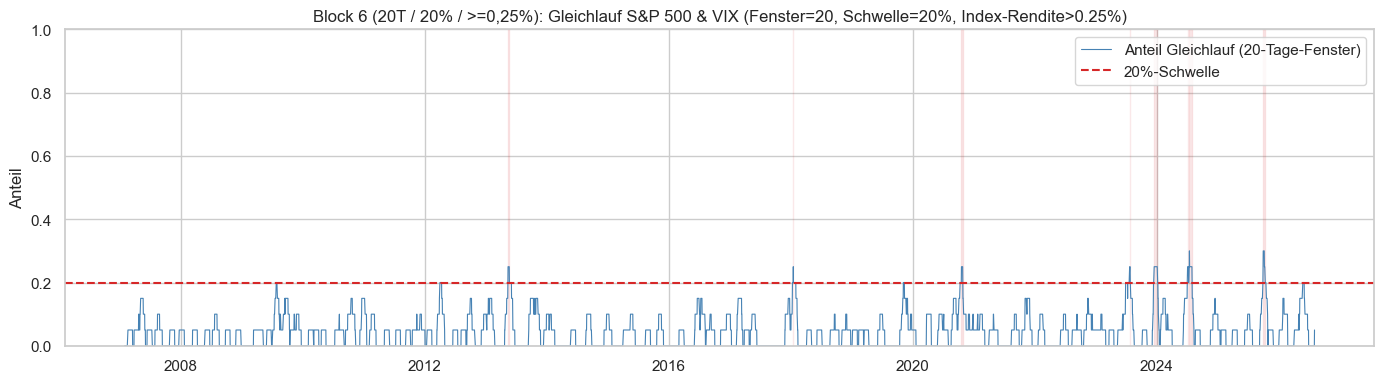

Signale: 56 von 4908 Fenstern (1.14%)
P(VIX > 30 in 10 Tagen | Signal): 25.0%  (Baseline: 15.2%)


In [25]:
_ = run_divergence_variant("Block 6 (20T / 20% / >=0,25%)", window=20, threshold=0.2, ret_min=0.25)


**Interpretation:** Diese Variante ist die einzige, die die Baseline klar schlaegt: 56 Signale bei einer Trefferquote von 25,0 % gegenueber 15,2 % Baseline (Faktor ~1,6). Ein ueber einen vollen Handelsmonat (20 Tage) anhaltender, substanzieller Gleichlauf (mindestens 20 % der Tage mit gleichzeitigem, spuerbarem Index-Anstieg und VIX-Anstieg) scheint tatsaechlich ein struktureller Vorbote erhoehter Turbulenz zu sein -- im Gegensatz zum kurzfristigen Rauschen aus Block 3. Mit 56 Beobachtungen ist die Aussage zudem deutlich belastbarer als die Original-Variante mit nur 5 Faellen.

#### Zusammenfassende Uebersicht aller 7 Varianten

Gegenueberstellung von Signalanzahl und Trefferquote (P(VIX > 30 in 10 Tagen | Signal)) je Parameterkombination. Die Baseline (unbedingte Wahrscheinlichkeit) dient als Referenz: Nur wenn die Trefferquote klar ueber der Baseline liegt UND gleichzeitig genug Signale vorliegen, ist eine Variante als Fruehindikator belastbar.


                               Fenster Schwelle Rendite-Min  Signale  Fenster (n) Trefferquote Baseline
Original (5T / 60% / >0%)            5      60%      >0.00%        5         4923         0.0%    15.2%
Block 1 (10T / 60% / >0%)           10      60%      >0.00%        0         4918          n/a    15.2%
Block 2 (20T / 60% / >0%)           20      60%      >0.00%        0         4908          n/a    15.2%
Block 3 (5T / 20% / >0%)             5      20%      >0.00%      471         4923         6.2%    15.2%
Block 4 (5T / 60% / >=0,25%)         5      60%      >0.25%        0         4923          n/a    15.2%
Block 5 (10T / 20% / >=0,25%)       10      20%      >0.25%       88         4918        11.4%    15.2%
Block 6 (20T / 20% / >=0,25%)       20      20%      >0.25%       56         4908        25.0%    15.2%


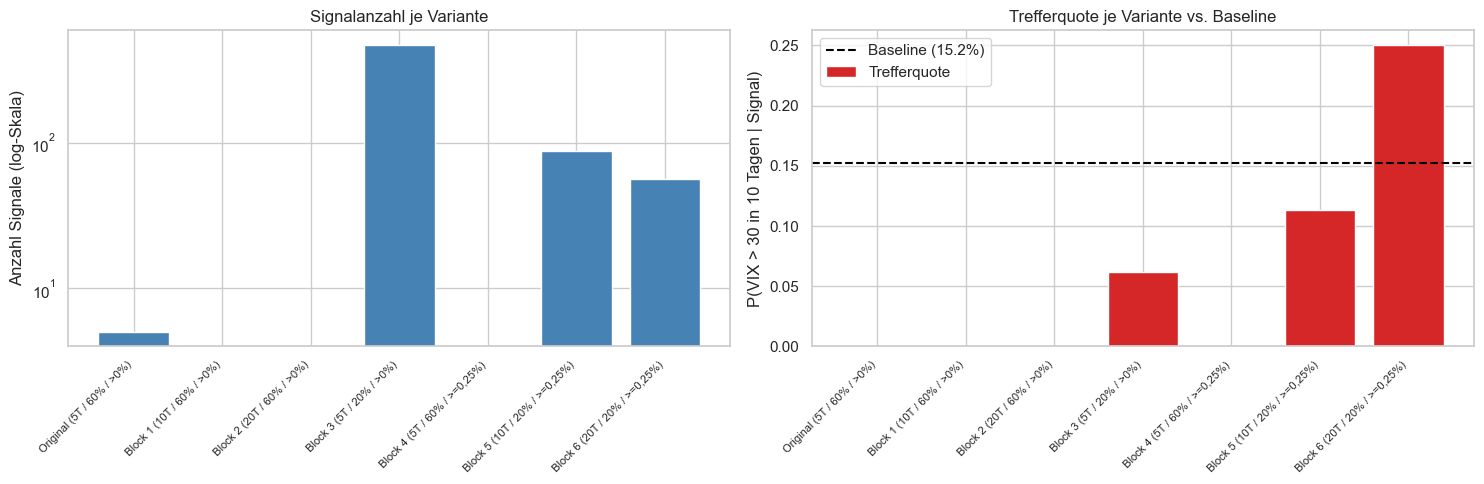

In [26]:
summary = pd.DataFrame(variant_results).T
summary = summary[["fenster", "schwelle", "rendite_min", "n_signale", "n_fenster", "trefferquote"]]
summary["fenster"] = summary["fenster"].astype(int)
summary["n_signale"] = summary["n_signale"].astype(int)
summary["n_fenster"] = summary["n_fenster"].astype(int)
summary["trefferquote"] = summary["trefferquote"].astype(float)

# Formatierte Anzeige-Tabelle
disp = summary.copy()
disp["schwelle"] = disp["schwelle"].map(lambda x: f"{x:.0%}")
disp["rendite_min"] = disp["rendite_min"].map(lambda x: f">{x:.2f}%")
disp["trefferquote"] = summary["trefferquote"].map(lambda x: f"{x:.1%}" if pd.notna(x) else "n/a")
disp["baseline"] = f"{baseline_10:.1%}"
disp = disp.rename(columns={
    "fenster": "Fenster", "schwelle": "Schwelle", "rendite_min": "Rendite-Min",
    "n_signale": "Signale", "n_fenster": "Fenster (n)", "trefferquote": "Trefferquote",
    "baseline": "Baseline",
})
print(disp.to_string())

# Visualisierung: Signalanzahl (log) und Trefferquote vs. Baseline
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
names = list(summary.index)
x = np.arange(len(names))

axes[0].bar(x, summary["n_signale"], color="steelblue")
axes[0].set_yscale("log")
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, rotation=45, ha="right", fontsize=8)
axes[0].set_ylabel("Anzahl Signale (log-Skala)")
axes[0].set_title("Signalanzahl je Variante")

hit_vals = summary["trefferquote"].fillna(0).values
axes[1].bar(x, hit_vals, color=COLOR_RED, label="Trefferquote")
axes[1].axhline(baseline_10, color="black", linestyle="--", label=f"Baseline ({baseline_10:.1%})")
axes[1].set_xticks(x)
axes[1].set_xticklabels(names, rotation=45, ha="right", fontsize=8)
axes[1].set_ylabel("P(VIX > 30 in 10 Tagen | Signal)")
axes[1].set_title("Trefferquote je Variante vs. Baseline")
axes[1].legend()

plt.tight_layout()
plt.show()


**Fazit der Varianten-Analyse:** Die Uebersicht zeigt einen klaren Trade-off zwischen Signalanzahl und Trennschaerfe. Die strengen 60 %-Varianten (Original sowie Block 1, 2 und 4) liefern 0-5 Signale und sind statistisch nicht auswertbar. Das blosse Absenken der Schwelle (Block 3: 5 Tage / 20 %) erzeugt zwar viele Signale, deren Trefferquote (6,2 %) aber unter der Baseline liegt -- kurzfristige Gleichlauf-Cluster sind kein Turbulenz-Vorbote. Erst die Kombination aus langem Fenster, niedriger Schwelle und Rendite-Filter dreht das Bild: Block 6 (20 Tage / 20 % / >=0,25 %) ist mit 56 Signalen und einer Trefferquote von 25,0 % (vs. 15,2 % Baseline) die einzige belastbare Variante mit echtem Vorhersage-Mehrwert. Fuer die Ampel-Logik empfiehlt sich damit -- falls Divergenz ueberhaupt genutzt wird -- ein langsam reagierender Indikator auf Monatsbasis (Block 6) als ergaenzendes Warnsignal, nicht die urspruengliche kurzfristige 5-Tage/60 %-Definition. Wichtig bleibt: Auch 56 Faelle sind fuer eine alleinige Ampel-Entscheidung noch knapp; die Divergenz taugt daher eher als Zusatzhinweis denn als eigenstaendiger Ausloeser.

## 13. Fazit

Die explorative Analyse bestaetigt, dass ein VIX-basiertes Ampel-System auf einer soliden empirischen Grundlage steht. Zusammenfassung der Befunde je Hypothese:

**Basis-Exploration:**

- **Hypothese 1 (Ruhiges Fahrwasser vs. Stressphasen):** Bestaetigt. Der VIX liegt an rund zwei Dritteln aller Tage unter 20 (Gruen 64,1 %, Gelb 26,8 %, Rot 9,1 %) und schiesst nur in realen Krisen deutlich ueber 30 (Spitzen 2008 und 2020 jenseits 80). Der VIX eignet sich damit als verstaendlicher Kernindikator.
- **Hypothese 2 (VIX vs. S&P-500-Renditen):** Bestaetigt fuer die Tagesaenderung (r = -0,815, stark invers), nicht fuer das Niveau (r = -0,143). Der VIX ist ein Zustands-, kein Richtungsindikator - Rot heisst 'erhoehte Vorsicht', nicht 'Markt faellt heute'.
- **Hypothese 3 (Volatility Clustering):** Bestaetigt. Sehr hohe Autokorrelation (Lag 1: 0,974, Lag 5: 0,909). Der VIX ist traege, die Ampel flackert bei reiner Schwellenwert-Logik nicht - ideal fuer eine taegliche Routine.
- **Hypothese 4 (Verteilung & Schwellenwerte):** Bestaetigt. Perzentile 50/75/90/95 = 17,5 / 22,7 / 29,1 / 35,3. Die Faustregeln (Gruen < 20, Gelb 20-30, Rot > 30) passen gut zur empirischen Verteilung.
- **Hypothese 5 (Dauer der Ampelphasen):** Bestaetigt/differenziert. 404 Phasenwechsel; Rot-Phasen sind meist kurz (Median 2 Tage), koennen in echten Krisen aber Monate dauern (max. 170 Tage, Finanzkrise 2008/09). Ein einzelner Rot-Tag sollte daher keine drastische Reaktion ausloesen - eine Eskalationsregel bei mehrtaegigem Rot ist sinnvoll.

**Vertiefende Hypothesen:**

- **Hypothese 9.1 (Neues 3-Monats-Hoch):** Bestaetigt als Fruehwarnsignal. 153 Signale; die Wahrscheinlichkeit fuer VIX > 30 in den Folgetagen steigt auf 39,2 % (5 Tage) bzw. 41,8 % (10 Tage) gegenueber einer Baseline von 12,3 % / 15,2 % (~Faktor 3), bleibt aber ein Minderheits-Ereignis. Geeignet als zusaetzliches 'Vorsicht'-Flag.
- **Hypothese 9.2 (3-Punkte-Umkehr):** Tendenziell bestaetigt als Beruhigungssignal. Bei 272 Signalen fiel der VIX in 67,3 % der Faelle nach 5 Tagen (im Schnitt -1,51 Punkte, Median -2,02). Nuetzlich als Entwarnungs-Hinweis innerhalb einer Gelb-/Rot-Phase, aber kein Automatismus.
- **Hypothese 9.3 (VIX-Schwellenwerte):** Bestaetigt. Der Median-VIX waehrend realer Stressphasen (31,77) liegt nahe am 90. Perzentil (29,11) und stuetzt die Rot-Schwelle von 30 datenbasiert; Gelb verortet sich im Bereich 75.-90. Perzentil (ca. 20-29). Zentrale Begruendung der gewaehlten Schwellenwerte.
- **Hypothese 9.4 (Divergenz zum Index):** In der urspruenglichen Definition (5 Tage / 60 % / Rendite > 0 %) nicht belastbar - nur 5 Signale, Trefferquote 0,0 % vs. Baseline 15,2 %. Die anschliessende Parameter-Robustheitspruefung (7 Varianten) zeigt jedoch einen klaren Trade-off zwischen Signalzahl und Trennschaerfe: Nur Block 6 (20 Tage / 20 % / Rendite >= 0,25 %) schlaegt die Baseline klar (56 Signale, Trefferquote 25,0 % vs. 15,2 %, ~Faktor 1,6) und kommt als langsames, ergaenzendes Zusatz-Warnsignal in Frage - nicht als eigenstaendiger Ausloeser.

**Abgeleitete Ampel-Logik (erster Entwurf):**

| Ampelfarbe | Basis-Kriterium | Optionaler Zusatzhinweis |
|---|---|---|
| Gruen | VIX < 20 | 'Vorsicht'-Flag bei aktivem 3-Monats-Hoch-Signal (9.1) |
| Gelb | 20 <= VIX < 30 | - |
| Rot | VIX >= 30 | Hinweis 'moegliche baldige Beruhigung' bei 3-Punkte-Umkehr (9.2) |

**Naechste Schritte:** Ampel-Logik inkl. Zusatzsignale als wiederverwendbare Funktion(en) in `src/` implementieren, einen historischen Backtest der kombinierten Regel durchfuehren (u.a. Anzahl/Dauer der Warnstufen, False-Positive-Rate), Unit-Tests mit den hier dokumentierten Kennzahlen als Referenzwerten schreiben und die Divergenz-Variante Block 6 (9.4) mit wachsender Datenbasis regelmaessig nachpruefen.